# Two coaxial long cylindrical shells: field profiles and graphics

This notebook accompanies the LaTeX derivation. The default model is the canonical coaxial pair:

- inner shell radius `a`, outer shell radius `b`
- inner shell charge per unit length `+lambda_per_length`, outer shell `-lambda_per_length`
- inner shell axial current `+I0`, outer shell axial current `-I0`
- homogeneous annular material with permittivity `eps` and permeability `mu`

The static fields are confined to the annular region `a < r < b`. The electrostatic fields are radial, the magnetostatic fields are circumferential, and a convenient vector potential is axial.

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Physical constants
_eps0 = 8.8541878128e-12
_mu0 = 4*np.pi*1e-7

# Geometry: two coaxial cylindrical shells
# You can change these values and rerun the notebook.
a = 1.0e-2      # inner radius, m
b = 5.0e-2      # outer radius, m

# Material in the annulus
eps_r = 1.0
mu_r = 1.0
eps = eps_r * _eps0
mu = mu_r * _mu0

# Source strengths for the canonical coaxial pair
lambda_per_length = 1.0e-9   # C/m on inner shell; outer shell has the negative
I0 = 1.0                     # A on inner shell; outer shell has the return current

# Useful derived constants
log_ba = np.log(b/a)
V0 = lambda_per_length/(2*np.pi*eps) * log_ba
Cprime = 2*np.pi*eps/log_ba
Lprime = mu/(2*np.pi)*log_ba
Z0 = np.sqrt(Lprime/Cprime)
v_phase = 1/np.sqrt(Lprime*Cprime)

print(f"a = {a:.4g} m, b = {b:.4g} m")
print(f"V0 = V(a)-V(b) = {V0:.6g} V")
print(f"C' = {Cprime:.6e} F/m")
print(f"L' = {Lprime:.6e} H/m")
print(f"Z0 = sqrt(L'/C') = {Z0:.6g} ohm")
print(f"1/sqrt(L'C') = {v_phase:.6e} m/s")

a = 0.01 m, b = 0.05 m
V0 = V(a)-V(b) = 28.9298 V
C' = 3.456642e-11 F/m
L' = 3.218876e-07 H/m
Z0 = sqrt(L'/C') = 96.4995 ohm
1/sqrt(L'C') = 2.997925e+08 m/s


## Helper functions

The functions below use the piecewise canonical coaxial solution:

- `electrostatic_profiles(r)` returns `D_r`, `E_r`, and `V`
- `magnetostatic_profiles(r)` returns `H_phi`, `B_phi`, and `A_z`
- `mqs_profiles(r,t)` returns the slowly time-varying fields for a sinusoidal current

In [8]:
def annulus(r):
    r = np.asarray(r)
    return (r >= a) & (r <= b)


def electrostatic_profiles(r, lam=lambda_per_length):
    # Return D_r, E_r, V for inner charge +lam and outer charge -lam.
    r = np.asarray(r, dtype=float)
    D = np.zeros_like(r)
    E = np.zeros_like(r)
    V = np.zeros_like(r)

    mask = annulus(r)
    inside = r < a

    D[mask] = lam/(2*np.pi*r[mask])
    E[mask] = D[mask]/eps
    V[mask] = lam/(2*np.pi*eps) * np.log(b/r[mask])
    V[inside] = lam/(2*np.pi*eps) * log_ba
    # V is set to zero outside r>b.
    return D, E, V


def magnetostatic_profiles(r, current=I0):
    # Return H_phi, B_phi, A_z for inner current +current and outer return current -current.
    r = np.asarray(r, dtype=float)
    H = np.zeros_like(r)
    B = np.zeros_like(r)
    A = np.zeros_like(r)

    mask = annulus(r)
    inside = r < a

    H[mask] = current/(2*np.pi*r[mask])
    B[mask] = mu*H[mask]
    A[mask] = mu*current/(2*np.pi) * np.log(b/r[mask])
    A[inside] = mu*current/(2*np.pi) * log_ba
    # Gauge choice: A_z = 0 for r>b.
    return H, B, A


def mqs_profiles(r, t, I_amplitude=I0, V_amplitude=V0, frequency=1.0e5):
    # Magnetoquasistatic snapshot.
    # I(t) = I_amplitude*sin(omega*t) and V0(t) = V_amplitude*cos(omega*t).
    # Returns radial electrostatic fields, axial inductive fields,
    # circumferential magnetic fields, and the potentials.
    r = np.asarray(r, dtype=float)
    omega = 2*np.pi*frequency
    It = I_amplitude*np.sin(omega*t)
    dIdt = I_amplitude*omega*np.cos(omega*t)
    Vt = V_amplitude*np.cos(omega*t)

    mask = annulus(r)
    inside = r < a

    Er = np.zeros_like(r)
    Dr = np.zeros_like(r)
    V = np.zeros_like(r)
    Ez_ind = np.zeros_like(r)
    Dz_ind = np.zeros_like(r)

    Er[mask] = Vt/(r[mask]*log_ba)
    Dr[mask] = eps*Er[mask]
    V[mask] = Vt*np.log(b/r[mask])/log_ba
    V[inside] = Vt

    # Gauge A_z(b,t)=0. Then E_z_ind = -partial A_z/partial t in the annulus.
    Ez_ind[mask] = -mu*dIdt/(2*np.pi)*np.log(b/r[mask])
    Dz_ind[mask] = eps*Ez_ind[mask]

    H, B, A = magnetostatic_profiles(r, current=It)

    return {
        "t": t,
        "I": It,
        "dIdt": dIdt,
        "V0": Vt,
        "Er": Er,
        "Dr": Dr,
        "V": V,
        "Ez_ind": Ez_ind,
        "Dz_ind": Dz_ind,
        "Hphi": H,
        "Bphi": B,
        "Az": A,
    }


def plot_profile(r, y, ylabel, title):
    plt.figure(figsize=(7.2, 4.2))
    plt.plot(r, y)
    plt.axvline(a, linestyle="--", linewidth=1)
    plt.axvline(b, linestyle="--", linewidth=1)
    plt.xlabel("radius r (m)")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.show()

## 1. Electrostatic profiles: D, E, and V

For the canonical pair, only the annulus has nonzero electric field. The potential is constant inside the inner shell and zero outside the outer shell under the gauge choice `V(b)=0`.

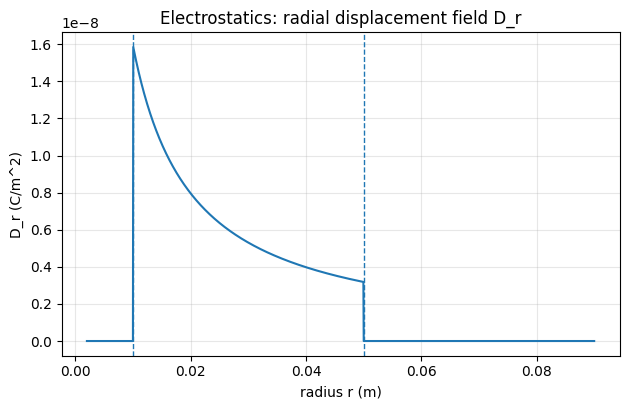

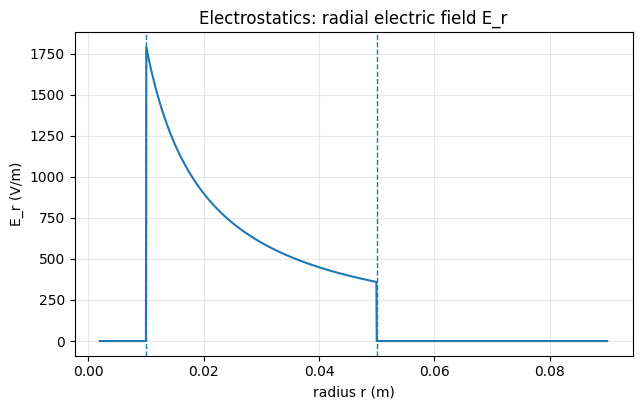

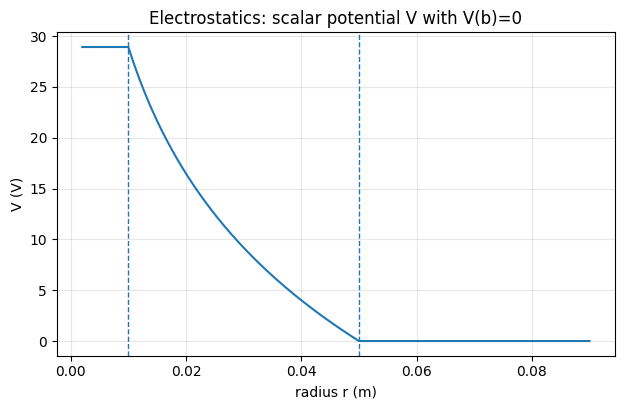

In [9]:
r = np.linspace(0.2*a, 1.8*b, 1500)
D_r, E_r, V = electrostatic_profiles(r)

plot_profile(r, D_r, "D_r (C/m^2)", "Electrostatics: radial displacement field D_r")
plot_profile(r, E_r, "E_r (V/m)", "Electrostatics: radial electric field E_r")
plot_profile(r, V, "V (V)", "Electrostatics: scalar potential V with V(b)=0")

## 2. Magnetostatic profiles: H, B, and A

The current is axial, so the magnetic field is circumferential. The vector potential is chosen as `A = A_z(r) zhat`, with gauge `A_z(b)=0` and `A_z=0` outside the outer shell.

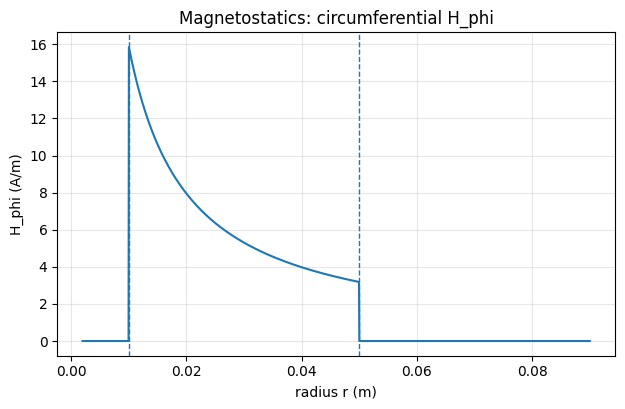

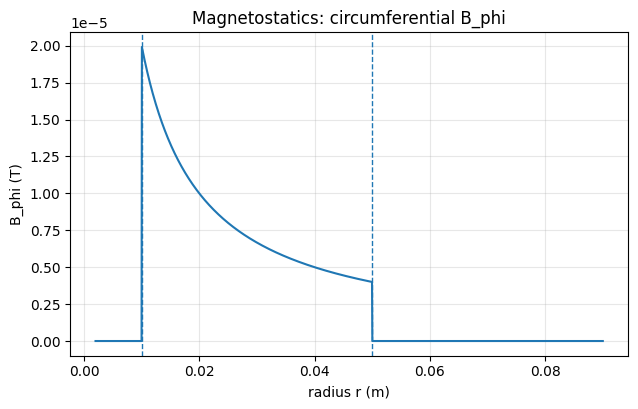

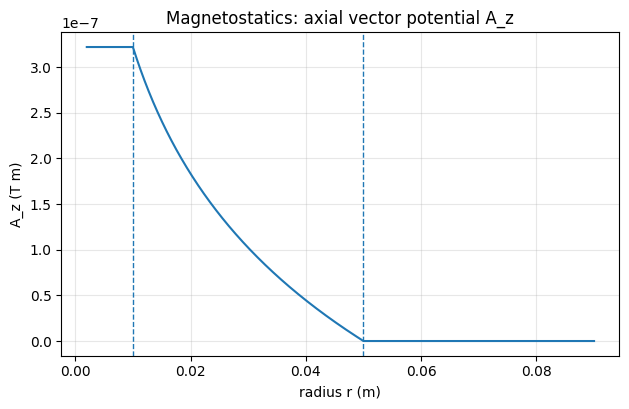

In [5]:
H_phi, B_phi, A_z = magnetostatic_profiles(r)

plot_profile(r, H_phi, "H_phi (A/m)", "Magnetostatics: circumferential H_phi")
plot_profile(r, B_phi, "B_phi (T)", "Magnetostatics: circumferential B_phi")
plot_profile(r, A_z, "A_z (T m)", "Magnetostatics: axial vector potential A_z")